In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('HAN_preprocessed.csv')
df

,id,brand,price,start_hour,end_hour,trip_hour,luggage,is_holiday,days_left
0,HAN0106,Bamboo Airways,2852590,Evening,LateNight,2.166667,7.0,2,1
1,HAN0624,VietJet Air,2770744,Evening,LateNight,2.083333,7.0,2,1
2,HAN0555,VietJet Air,2770744,Evening,Evening,2.166667,7.0,2,1
3,HAN0582,VietJet Air,2770744,Evening,Evening,2.166667,7.0,2,1
4,HAN0603,VietJet Air,2770744,Evening,LateNight,2.166667,7.0,2,1
...,...,...,...,...,...,...,...,...,...
19297,HAN1167,Vietnam Airlines,2817290,Evening,Evening,2.083333,35.0,1,11
19298,HAN0010,Bamboo Airways,2852590,Morning,Morning,2.166667,7.0,1,11
19299,HAN0037,Bamboo Airways,2852590,Afternoon,Afternoon,2.166667,7.0,1,11
19300,HAN0071,Bamboo Airways,2852590,Evening,Evening,2.166667,7.0,1,11


# EDA

In [4]:
df.describe()

,price,trip_hour,luggage,is_holiday,days_left
count,1.930200e+04,19302.000000,19302.000000,19302.000000,19302.000000
mean,2.534265e+06,2.131873,14.526681,0.891151,10.305253
std,6.524804e+05,0.042347,14.521681,1.039710,5.497400
min,1.241753e+06,1.916667,0.000000,0.000000,0.000000
25%,2.008244e+06,2.083333,7.000000,0.000000,6.000000
50%,2.421620e+06,2.166667,7.000000,0.000000,10.000000
75%,3.050946e+06,2.166667,35.000000,2.000000,15.000000
max,3.897009e+06,2.416667,35.000000,3.000000,20.000000


In [8]:
df[['price','trip_hour','luggage','is_holiday','days_left']].corr().T

,price,trip_hour,luggage,is_holiday,days_left
price,1.000000,-0.321508,0.391141,0.529713,-0.135080
trip_hour,-0.321508,1.000000,-0.585922,0.015571,0.011833
luggage,0.391141,-0.585922,1.000000,0.056712,-0.221408
is_holiday,0.529713,0.015571,0.056712,1.000000,0.059920
days_left,-0.135080,0.011833,-0.221408,0.059920,1.000000


## FLIGHT & AIRLINES

In [ ]:
df1 = df.groupby(['id', 'brand'], as_index=False).count()
df1.brand.value_counts()

brand
VietJet Air           8844
Vietnam Airlines      8192
Bamboo Airways        1886
Vietravel Airlines     380
Name: count, dtype: int64

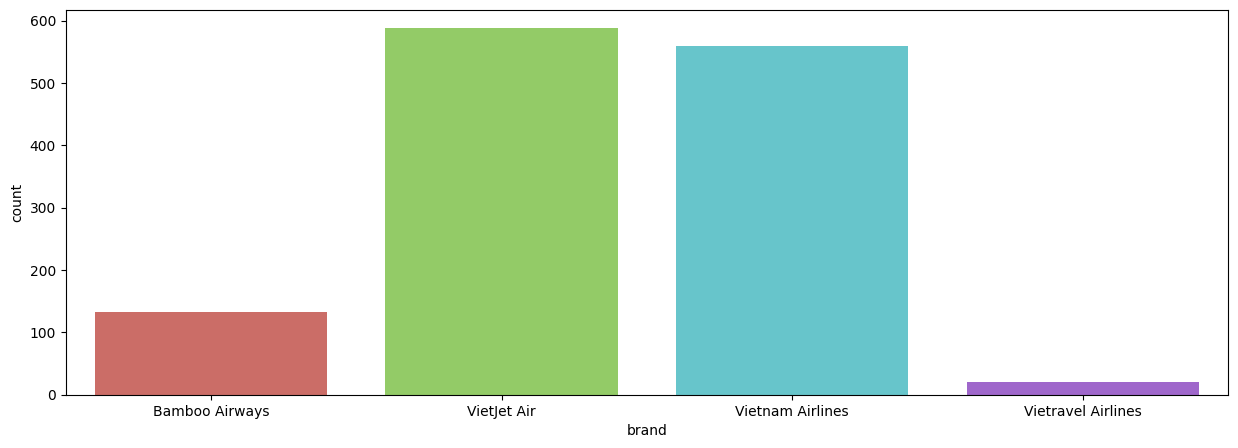

In [57]:
plt.figure(figsize=(15, 5))
sns.countplot(
    x='brand', 
    data=df1, 
    hue='brand', 
    palette='hls', 
    legend=False)
plt.show()

## PRICE & AIRLINES

In [53]:
df['price']

0        2852590
1        2770744
2        2770744
3        2770744
4        2770744
          ...   
19297    2817290
19298    2852590
19299    2852590
19300    2852590
19301    2852590
Name: price, Length: 19302, dtype: int64

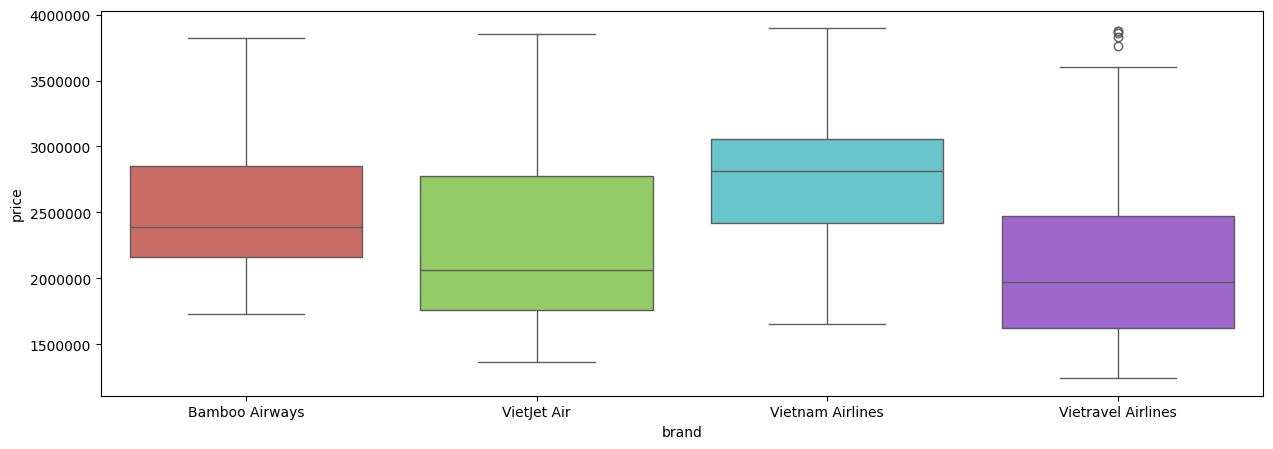

In [68]:
plt.figure(figsize=(15, 5))
sns.boxplot(
    x='brand', 
    y='price',
    data=df,
    hue='brand',
    palette='hls',
    legend=False
    )
plt.ticklabel_format(style='plain', axis='y')

PRICE: 
- max: VietNam
- min: Viettravel

PRICE RANGE:
- max: Vietjet
- min: Vietnam

UNUSUAL: Viettravel

RIGHT-SKEWED: Bamboo, VietJet, Viettravel

## PRICE & TIME

<Axes: xlabel='end_hour', ylabel='price'>

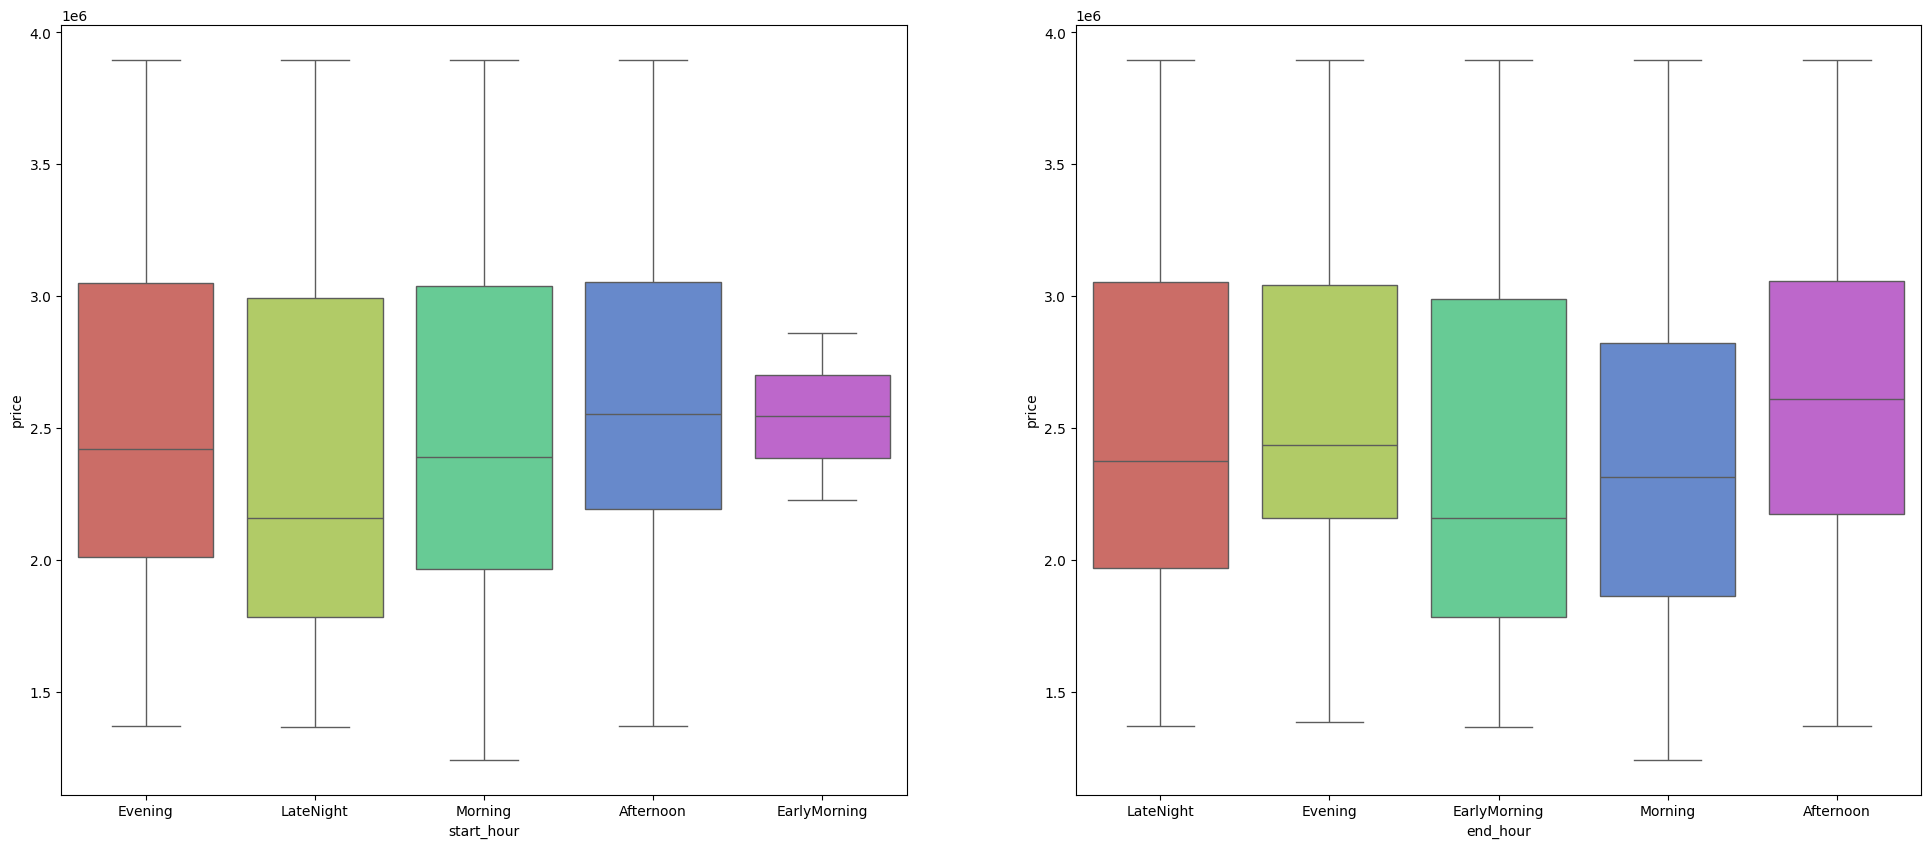

In [73]:
plt.figure(figsize=(24,10))

plt.subplot(1, 2, 1)
sns.boxplot(x='start_hour', y='price', data=df,
            hue='start_hour', palette='hls', legend=False)

plt.subplot(1, 2, 2)
sns.boxplot(x='end_hour', y='price', data=df,
            hue='end_hour', palette='hls', legend=False)

the price max is mostly the same for all category:
- biggest price range: LateNight (21h-24h)
- smallest price range + the most stable: Early Morning (0h-3h)

## PRICE & DESTINATION

## PRICE & TRIP_TIME

In [81]:
df['trip_hour'].value_counts()

trip_hour
2.166667    11294
2.083333     7880
2.000000       95
2.250000       26
1.916667        6
2.416667        1
Name: count, dtype: int64

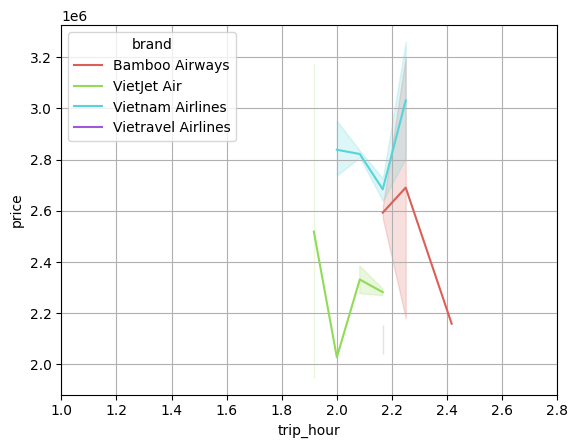

In [84]:
sns.lineplot(data=df, x='trip_hour', y='price', hue='brand', palette='hls')
plt.xticks(np.arange(1.0, 3.0, 0.2))
plt.grid(True)
plt.show()


## PRICE & DAYS_LEFT

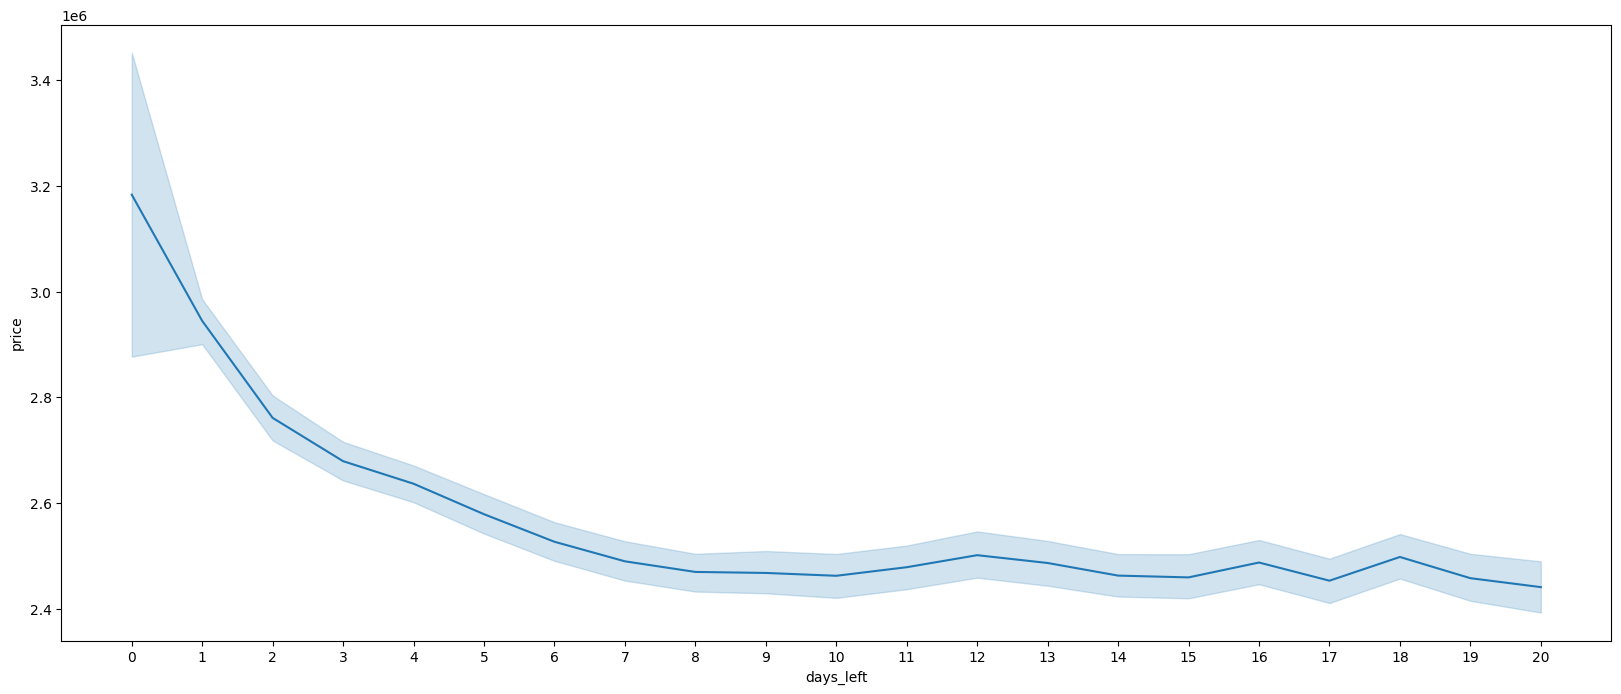

In [97]:
plt.figure(figsize=(20,8))
sns.lineplot(x='days_left', y='price', data=df)
# plt.gca().invert_xaxis()
plt.xticks(np.arange(20, -1, -1))
plt.show()

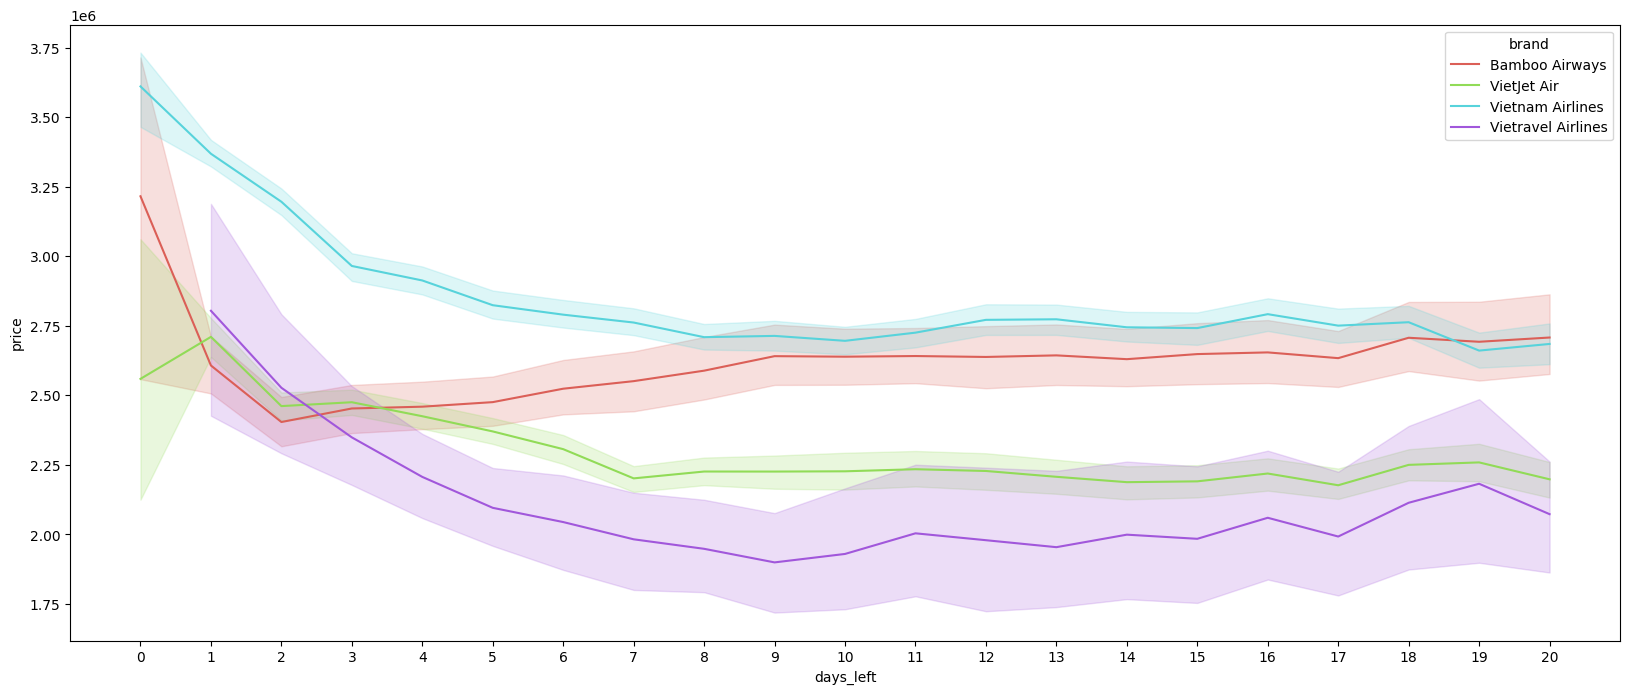

In [96]:
plt.figure(figsize=(20,8))
sns.lineplot(
    x='days_left', y='price', data=df,
    hue='brand', palette='hls')
# plt.gca().invert_xaxis()
plt.xticks(np.arange(20, -1, -1))
plt.show()

# MODELING by kaggel

In [99]:
data = df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          19302 non-null  object 
 1   brand       19302 non-null  object 
 2   price       19302 non-null  int64  
 3   start_hour  19302 non-null  object 
 4   end_hour    19302 non-null  object 
 5   trip_hour   19302 non-null  float64
 6   luggage     19302 non-null  float64
 7   is_holiday  19302 non-null  int64  
 8   days_left   19302 non-null  int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 1.3+ MB


In [100]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [101]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15441, 8), (3861, 8), (15441,), (3861,))

In [102]:
from sklearn.preprocessing import MinMaxScaler
mmscaler = MinMaxScaler(feature_range=(0, 1))
X_train = mmscaler.fit_transform(X_train)
X_test = mmscaler.transform(X_test)
X_train=pd.DataFrame(X_train)
X_test=pd.DataFrame(X_test)

In [103]:
a={'Model Name':[], 'Mean_Absolute_Error_MAE':[] ,'Adj_R_Square':[] ,'Root_Mean_Squared_Error_RMSE':[] ,'Mean_Absolute_Percentage_Error_MAPE':[] ,'Mean_Squared_Error_MSE':[] ,'Root_Mean_Squared_Log_Error_RMSLE':[] ,'R2_score':[]}
Results=pd.DataFrame(a)
Results.head()

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score


In [104]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 5.0 MB/s eta 0:00:30
   ---------------------------------------- 1.0/150.0 MB 5.0 MB/s eta 0:00:30
    --------------------------------------- 2.4/150.0 MB 4.4 MB/s eta 0:00:34
    --------------------------------------- 2.6/150.0 MB 4.6 MB/s eta 0:00:33
    --------------------------------------- 2.9/150.0 MB 3.2 MB/s eta 0:00:46
    --------------------------------------- 3.4/150.0 MB 3.0 MB/s eta 0:00:49
   - -------------------------------------- 4.5/150.0 MB 3.2 MB/s eta 0:00:46
   - -------------------------------------- 5.2/150.0 MB 3.4 MB/s eta 0:00:44
   - -------------------------------------- 5.8/150.0 MB 3.4 MB/s eta 0:00:42
   - -------------------------------------- 6.0/150.0 MB 3.2 MB/s eta 0:00:46
   - -------------------------------------- 6.3/150.0 MB 2.9 MB/s eta 0:00:50
   - -------------------------------------- 7.3/150.0 MB 3.0 MB/s eta 0

In [106]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import metrics

In [112]:
modelmlg = LinearRegression()
modeldcr = DecisionTreeRegressor()
modelbag = BaggingRegressor()
modelrfr = RandomForestRegressor()
modelSVR = SVR()
modelXGR = xgb.XGBRegressor()
modelKNN = KNeighborsRegressor(n_neighbors=5)
modelETR = ExtraTreesRegressor()
modelRE=Ridge()
modelLO=linear_model.Lasso(alpha=0.1)

In [115]:
modelGBR = GradientBoostingRegressor(loss='squared_error', learning_rate=0.1, n_estimators=100, subsample=1.0,
                                     criterion='friedman_mse', min_samples_split=2, min_samples_leaf=1,
                                     min_weight_fraction_leaf=0.0, max_depth=3, min_impurity_decrease=0.0,
                                     init=None, random_state=None, max_features=None,
                                     alpha=0.9, verbose=0, max_leaf_nodes=None, warm_start=False,
                                     validation_fraction=0.1, n_iter_no_change=None, tol=0.0001, ccp_alpha=0.0)

# Evalution matrix for all the algorithms

MM = [modelmlg, modeldcr, modelrfr, modelKNN, modelETR, modelGBR, modelXGR, modelbag,modelRE,modelLO]

for models in MM:
    
    # Fit the model with train data
    
    models.fit(X_train, y_train)
    
    # Predict the model with test data

    y_pred = models.predict(X_test)
    
    # Print the model name
    
    print('Model Name: ', models)

    print('Mean Absolute Error (MAE):', round(metrics.mean_absolute_error(y_test, y_pred),3))  
    print('Mean Squared Error (MSE):', round(metrics.mean_squared_error(y_test, y_pred),3))  
    print('Root Mean Squared Error (RMSE):', round(np.sqrt(metrics.mean_squared_error(y_test, y_pred)),3))
    print('R2_score:', round(metrics.r2_score(y_test, y_pred),6))
    print('Root Mean Squared Log Error (RMSLE):', round(np.log(np.sqrt(metrics.mean_squared_error(y_test, y_pred))),3))
    
    # Define the function to calculate the MAPE - Mean Absolute Percentage Error

    def MAPE (y_test, y_pred):
        y_test, y_pred = np.array(y_test), np.array(y_pred)
        return np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    # Evaluation of MAPE 

    result = MAPE(y_test, y_pred)
    print('Mean Absolute Percentage Error (MAPE):', round(result, 2), '%')
    
    # Calculate Adjusted R squared values 
    r_squared = round(metrics.r2_score(y_test, y_pred),6)
    adjusted_r_squared = round(1 - (1-r_squared)*(len(y)-1)/(len(y)-X.shape[1]-1),6)
    print('Adj R Square: ', adjusted_r_squared)
    print('------------------------------------------------------------------------------------------------------------')
    #-------------------------------------------------------------------------------------------
    new_row = {'Model Name' : models,
               'Mean_Absolute_Error_MAE' : metrics.mean_absolute_error(y_test, y_pred),
               'Adj_R_Square' : adjusted_r_squared,
               'Root_Mean_Squared_Error_RMSE' : np.sqrt(metrics.mean_squared_error(y_test, y_pred)),
               'Mean_Absolute_Percentage_Error_MAPE' : result,
               'Mean_Squared_Error_MSE' : metrics.mean_squared_error(y_test, y_pred),
               'Root_Mean_Squared_Log_Error_RMSLE': np.log(np.sqrt(metrics.mean_squared_error(y_test, y_pred))),
               'R2_score' : metrics.r2_score(y_test, y_pred)}
    Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
    #------------------------------------------------------------

Model Name:  LinearRegression()
Mean Absolute Error (MAE): 391704.585
Mean Squared Error (MSE): 239959281462.133
Root Mean Squared Error (RMSE): 489856.389
R2_score: 0.446654
Root Mean Squared Log Error (RMSLE): 13.102
Mean Absolute Percentage Error (MAPE): 15.94 %
Adj R Square:  0.446425
------------------------------------------------------------------------------------------------------------
Model Name:  DecisionTreeRegressor()
Mean Absolute Error (MAE): 167342.554
Mean Squared Error (MSE): 100161284703.947
Root Mean Squared Error (RMSE): 316482.677
R2_score: 0.769028
Root Mean Squared Log Error (RMSLE): 12.665
Mean Absolute Percentage Error (MAPE): 6.57 %
Adj R Square:  0.768932
------------------------------------------------------------------------------------------------------------
Model Name:  RandomForestRegressor()
Mean Absolute Error (MAE): 162898.239
Mean Squared Error (MSE): 67463321596.707
Root Mean Squared Error (RMSE): 259737.024
R2_score: 0.84443
Root Mean Squared Lo

In [116]:
Results

,Model Name,Mean_Absolute_Error_MAE,Adj_R_Square,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score
0,LinearRegression(),391704.584517,0.446425,489856.388610,15.938676,2.399593e+11,13.101868,0.446654
1,DecisionTreeRegressor(),166878.500907,0.771382,314800.745484,6.554354,9.909951e+10,12.659695,0.771477
2,"(DecisionTreeRegressor(max_features=1.0, rando...",162864.187411,0.843201,260706.722717,6.334500,6.796800e+10,12.471151,0.843266
3,KNeighborsRegressor(),272994.595442,0.684473,369826.660357,10.899912,1.367718e+11,12.820790,0.684604
4,"(ExtraTreeRegressor(random_state=1502066378), ...",216394.050396,0.750434,328907.284778,8.474340,1.081800e+11,12.703531,0.750537
5,LinearRegression(),391704.584517,0.446425,489856.388610,15.938676,2.399593e+11,13.101868,0.446654
6,DecisionTreeRegressor(),167342.553743,0.768932,316482.676783,6.573368,1.001613e+11,12.665024,0.769028
7,"(DecisionTreeRegressor(max_features=1.0, rando...",162898.238660,0.844365,259737.023924,6.342921,6.746332e+10,12.467425,0.844430
8,KNeighborsRegressor(),272994.595442,0.684473,369826.660357,10.899912,1.367718e+11,12.820790,0.684604
9,"(ExtraTreeRegressor(random_state=1502066378), ...",215449.336476,0.751466,328226.325585,8.448979,1.077325e+11,12.701459,0.751569


In [117]:
models=['LinearRegression','DecisionTreeRegressor','RandomForestRegressor','KNeighborsRegressor','ExtraTreesRegressor','GradientBoostingRegressor','XGBRegressor','BaggingRegressor','Ridge Regression','Lasso Regression']
result=pd.DataFrame({'Model_Name':models})
result['Adj_R_Square']=Results['Adj_R_Square']
result['Mean_Absolute_Error_MAE']=Results['Mean_Absolute_Error_MAE']
result['Root_Mean_Squared_Error_RMSE']=Results['Root_Mean_Squared_Error_RMSE']
result['Mean_Absolute_Percentage_Error_MAPE']=Results['Mean_Absolute_Percentage_Error_MAPE']
result['Mean_Squared_Error_MSE']=Results['Mean_Squared_Error_MSE']
result['Root_Mean_Squared_Log_Error_RMSLE']=Results['Root_Mean_Squared_Log_Error_RMSLE']
result['R2_score']=Results['R2_score']
result=result.sort_values(by='Adj_R_Square',ascending=False).reset_index(drop=True)
result

,Model_Name,Adj_R_Square,Mean_Absolute_Error_MAE,Root_Mean_Squared_Error_RMSE,Mean_Absolute_Percentage_Error_MAPE,Mean_Squared_Error_MSE,Root_Mean_Squared_Log_Error_RMSLE,R2_score
0,BaggingRegressor,0.844365,162898.238660,259737.023924,6.342921,6.746332e+10,12.467425,0.844430
1,RandomForestRegressor,0.843201,162864.187411,260706.722717,6.334500,6.796800e+10,12.471151,0.843266
2,DecisionTreeRegressor,0.771382,166878.500907,314800.745484,6.554354,9.909951e+10,12.659695,0.771477
3,XGBRegressor,0.768932,167342.553743,316482.676783,6.573368,1.001613e+11,12.665024,0.769028
4,Lasso Regression,0.751466,215449.336476,328226.325585,8.448979,1.077325e+11,12.701459,0.751569
5,ExtraTreesRegressor,0.750434,216394.050396,328907.284778,8.474340,1.081800e+11,12.703531,0.750537
6,Ridge Regression,0.684473,272994.595442,369826.660357,10.899912,1.367718e+11,12.820790,0.684604
7,KNeighborsRegressor,0.684473,272994.595442,369826.660357,10.899912,1.367718e+11,12.820790,0.684604
8,LinearRegression,0.446425,391704.584517,489856.388610,15.938676,2.399593e+11,13.101868,0.446654
9,GradientBoostingRegressor,0.446425,391704.584517,489856.388610,15.938676,2.399593e+11,13.101868,0.446654


In [118]:
#Trainig the model with
modelETR.fit(X_train, y_train)
    
# Predict the model with test data

y_pred = modelETR.predict(X_test)
out=pd.DataFrame({'Price_actual':y_test,'Price_pred':y_pred})
result=df.merge(out,left_index=True,right_index=True)
result.sample(10)

,id,brand,price,start_hour,end_hour,trip_hour,luggage,is_holiday,days_left,Price_actual,Price_pred
7834,687,1,2789010,3,1,2.166667,7.0,2,13,2789010,2867413.78
15322,983,2,2436133,0,2,2.083333,0.0,3,6,2436133,2887911.80
8040,430,1,3681773,0,2,2.166667,7.0,2,16,3681773,3494680.67
13306,619,1,1746623,2,3,2.166667,7.0,1,19,1746623,1597992.40
8309,315,1,3070305,4,0,2.083333,7.0,0,4,3070305,2608580.30
5742,1106,2,2809188,2,2,2.083333,0.0,1,14,2809188,2976700.32
13094,1094,2,2222662,2,2,2.083333,35.0,0,14,2222662,2683441.53
12148,403,1,1862333,0,0,2.166667,7.0,0,18,1862333,1804917.04
14853,748,2,2436133,4,4,2.083333,0.0,0,13,2436133,2287977.40
11239,954,2,3696736,0,2,2.083333,35.0,0,1,3696736,2967170.93


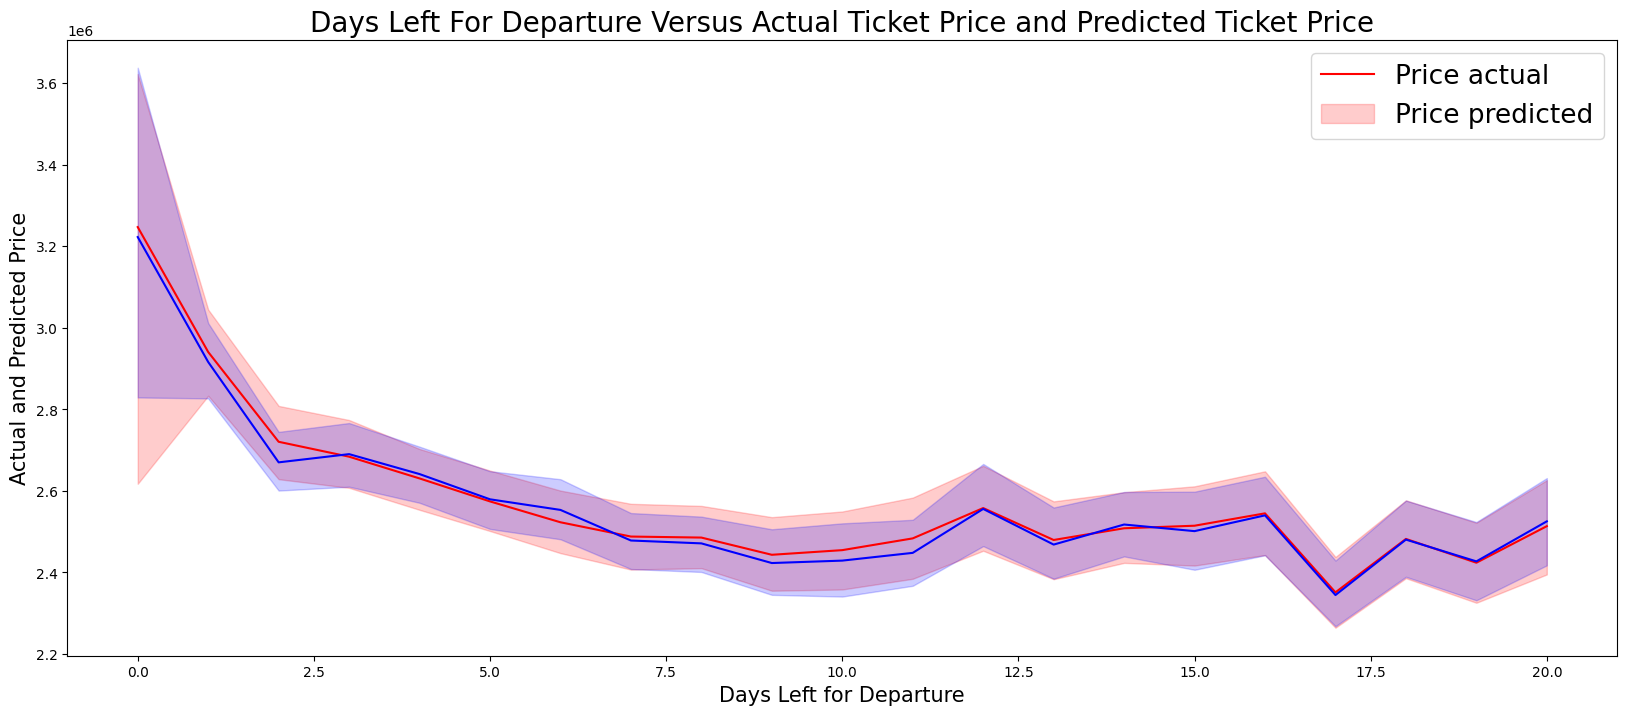

In [119]:
plt.figure(figsize=(20,8))
sns.lineplot(data=result,x='days_left',y='Price_actual',color='red')
sns.lineplot(data=result,x='days_left',y='Price_pred',color='blue')
plt.title('Days Left For Departure Versus Actual Ticket Price and Predicted Ticket Price',fontsize=20)
plt.legend(labels=['Price actual','Price predicted'],fontsize=19)
plt.xlabel('Days Left for Departure',fontsize=15)
plt.ylabel('Actual and Predicted Price',fontsize=15)
plt.show()

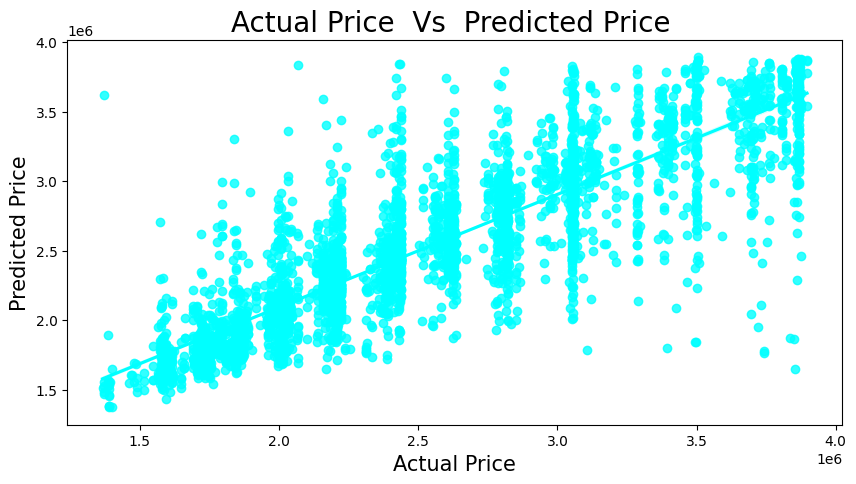

In [120]:
plt.figure(figsize=(10,5))
sns.regplot(x='Price_actual',y='Price_pred',data=result,color='cyan')
plt.title('Actual Price  Vs  Predicted Price ',fontsize=20)
plt.xlabel('Actual Price',fontsize=15)
plt.ylabel('Predicted Price',fontsize=15)
plt.show()

# MODELING

In [123]:
df = data.copy()
df.shape

(19302, 9)

In [122]:
df.head()

,id,brand,price,start_hour,end_hour,trip_hour,luggage,is_holiday,days_left
0,HAN0106,Bamboo Airways,2852590,Evening,LateNight,2.166667,7.0,2,1
1,HAN0624,VietJet Air,2770744,Evening,LateNight,2.083333,7.0,2,1
2,HAN0555,VietJet Air,2770744,Evening,Evening,2.166667,7.0,2,1
3,HAN0582,VietJet Air,2770744,Evening,Evening,2.166667,7.0,2,1
4,HAN0603,VietJet Air,2770744,Evening,LateNight,2.166667,7.0,2,1


In [140]:
df_sorted = df.sort_values(by=['id', 'days_left'], ascending=[True, False])

df['min_price_so_far'] = df_sorted.groupby('id')['price'].cummin()
df['max_price_so_far'] = df_sorted.groupby('id')['price'].cummax()

df = df_sorted.sort_values(by=['id', 'days_left'], ascending=[True, True])

In [141]:
df[df['id'] == 'HAN0555'][['id', 'days_left', 'price', 'min_price_so_far', 'max_price_so_far']].sort_values(by='days_left', ascending=False)

,id,days_left,price,min_price_so_far,max_price_so_far
4697,HAN0555,20,2970000,2970000,2970000
5320,HAN0555,19,2957140,2957140,2970000
5981,HAN0555,18,3081278,2957140,3081278
6685,HAN0555,17,3090255,2957140,3090255
7366,HAN0555,16,3101228,2957140,3101228
7984,HAN0555,15,3069308,2957140,3101228
8866,HAN0555,14,3364568,2957140,3364568
9780,HAN0555,13,3412448,2957140,3412448
10758,HAN0555,12,3411450,2957140,3412448
11796,HAN0555,11,3398483,2957140,3412448


    STEP 1: load raw data
    """
    load_for_classification_for_Specific()
    load_for_classification_for_General()

    """

In [ ]:

    """
    Load the data for classification
    :param dataset: dataset name('Specific' or 'General')
    :return: X_train, y_train, X_test, y_test
    """
    isOneOptimalState = False
    # Construct the input data
    dim = routes.__len__() + 4
    X_train = np.empty(shape=(0, dim))
    y_train = np.empty(shape=(0,1))
    y_train_price = np.empty(shape=(0,1))
    X_test = np.empty(shape=(0,dim))
    y_test = np.empty(shape=(0,1))
    y_test_price = np.empty(shape=(0,1))

    for filePrefix in routes:
        datas = load_data_with_prefix_and_dataset(filePrefix, dataset)
        for data in datas:
            print "Construct route {}, State {}, departureDate {}...".format(filePrefix, data["State"], data["Date"])
            x_i = []
            # feature 1: flight number -> dummy variables
            for i in range(len(routes)):
                """
                !!!need to change!
                """
                if i == routes.index(filePrefix):
                    x_i.append(1)
                else:
                    x_i.append(0)

            # feature 2: departure date interval from "20151109", because the first observed date is 20151109
            departureDate = data["Date"]
            """
            !!!maybe need to change the first observed date
            """
            departureDateGap = util.days_between(departureDate, "20151109")
            x_i.append(departureDateGap)

            # feature 3: observed days before departure date
            state = data["State"]
            x_i.append(state)

            # feature 4: minimum price before the observed date
            minimumPreviousPrice = getMinimumPreviousPrice(data["Date"], state, datas)
            x_i.append(minimumPreviousPrice)

            # feature 5: maximum price before the observed date
            maximumPreviousPrice = getMaximumPreviousPrice(data["Date"], state, datas)
            x_i.append(maximumPreviousPrice)

            # output
            y_i = [0]
            specificDatas = []
            specificDatas = [data2 for data2 in datas if data2["Date"]==departureDate]

            # if isOneOptimalState:
            #     # Method 1: only 1 entry is buy
            #     optimalState = getOptimalState(specificDatas)
            #     if data["State"] == optimalState:
            #        y_i = [1]
            # else:
            #     # Method 2: multiple entries can be buy
            #     minPrice = getMinimumPrice(specificDatas)
            #     if util.getPrice(data["MinimumPrice"]) == minPrice:
            #         y_i = [1]

            #Method 2: multiple entries can be buy
            minPrice = getMinimumPrice(specificDatas)
            if util.getPrice(data["MinimumPrice"]) == minPrice:
                y_i = [1]


            # keep price info
            y_price = [util.getPrice(data["MinimumPrice"])]

            if int(departureDate) < 20160229 and int(departureDate) >= 20151129: # choose date between "20151129-20160229(20160115)" as training data
                X_train = np.concatenate((X_train, [x_i]), axis=0)
                y_train = np.concatenate((y_train, [y_i]), axis=0)
                y_train_price = np.concatenate((y_train_price, [y_price]), axis=0)
            elif int(departureDate) < 20160508 and int(departureDate) >= 20160229: # choose date before "20160508(20160220)" as test data
                X_test = np.concatenate((X_test, [x_i]), axis=0)
                y_test = np.concatenate((y_test, [y_i]), axis=0)
                y_test_price = np.concatenate((y_test_price, [y_price]), axis=0)
            else:
                pass

            # X_train = np.concatenate((X_train, [x_i]), axis=0)
            # y_train = np.concatenate((y_train, [y_i]), axis=0)
            # y_train_price = np.concatenate((y_train_price, [y_price]), axis=0)

        # end of for datas
    # end of for routes


    """
    remove duplicate rows for train
    """
    tmp_train = np.concatenate((X_train, y_train, y_train_price), axis=1)
    new_array = [tuple(row) for row in tmp_train]
    tmp_train = np.unique(new_array)

    # get the result
    X_train = tmp_train[:, 0:12]
    y_train = tmp_train[:, 12]
    y_train_price = tmp_train[:, 13]

    """
    remove duplicate rows for test
    """
    tmp_test = np.concatenate((X_test, y_test, y_test_price), axis=1)
    new_array = [tuple(row) for row in tmp_test]
    tmp_test = np.unique(new_array)

    # get the result
    X_test = tmp_test[:, 0:12]
    y_test = tmp_test[:, 12]
    y_test_price = tmp_test[:, 13]

    # save the result
    np.save('inputSpecificRaw/X_train', X_train)
    np.save('inputSpecificRaw/y_train', y_train)
    np.save('inputSpecificRaw/y_train_price', y_train_price)
    np.save('inputSpecificRaw/X_test', X_test)
    np.save('inputSpecificRaw/y_test', y_test)
    np.save('inputSpecificRaw/y_test_price', y_test_price)

    return X_train, y_train, X_test, y_test

# step 1. The main data load function - for classification for the general dataset
"""
def load_for_classification_for_General(dataset="General", routes=routes_general):
    """
    Load the data for classification
    :param dataset: dataset name('Specific' or 'General')
    :return: X_train, y_train, X_test, y_test
    """
    isOneOptimalState = False
    # Construct the input data
    dim = routes.__len__() + 4
    X_train = np.empty(shape=(0, dim))
    y_train = np.empty(shape=(0,1))
    y_train_price = np.empty(shape=(0,1))

    for filePrefix in routes:
        print filePrefix
        datas = load_data_with_prefix_and_dataset(filePrefix, dataset)
        for data in datas:
            print "Construct route {}, State {}, departureDate {}...".format(filePrefix, data["State"], data["Date"])
            x_i = []
            # feature 1: flight number -> dummy variables
            for i in range(len(routes)):
                """
                !!!need to change!
                """
                if i == routes.index(filePrefix):
                    x_i.append(1)
                else:
                    x_i.append(0)

            # feature 2: departure date interval from "20151109", because the first observed date is 20151109
            departureDate = data["Date"]
            """
            !!!maybe need to change the first observed date
            """
            departureDateGap = util.days_between(departureDate, "20151109")
            x_i.append(departureDateGap)

            # feature 3: observed days before departure date
            state = data["State"]
            x_i.append(state)

            # feature 4: minimum price before the observed date
            minimumPreviousPrice = getMinimumPreviousPrice(data["Date"], state, datas)
            x_i.append(minimumPreviousPrice)

            # feature 5: maximum price before the observed date
            maximumPreviousPrice = getMaximumPreviousPrice(data["Date"], state, datas)
            x_i.append(maximumPreviousPrice)

            # output
            y_i = [0]
            specificDatas = []
            specificDatas = [data2 for data2 in datas if data2["Date"]==departureDate]

            minPrice = getMinimumPrice(specificDatas)
            if util.getPrice(data["MinimumPrice"]) == minPrice:
                y_i = [1]


            # keep price info
            y_price = [util.getPrice(data["MinimumPrice"])]

            X_train = np.concatenate((X_train, [x_i]), axis=0)
            y_train = np.concatenate((y_train, [y_i]), axis=0)
            y_train_price = np.concatenate((y_train_price, [y_price]), axis=0)

        # end of for datas
    # end of for routes


    """
    remove duplicate rows
    """
    tmp = np.concatenate((X_train, y_train, y_train_price), axis=1)
    new_array = [tuple(row) for row in tmp]
    tmp = np.unique(new_array)

    # # get the result
    # X_train = tmp[:, 0:16]
    # y_train = tmp[:, 16]
    # y_train_price = tmp[:, 17]

    # save the result
    np.save('inputGeneralRaw/X_train', X_train)
    np.save('inputGeneralRaw/y_train', y_train)
    np.save('inputGeneralRaw/y_train_price', y_train_price)
    np.save('inputGeneralRaw/tmp', tmp)

    return X_train, y_train, y_train_price


    STEP 2: get the data for the classification problem
    """
    priceNormalize_for_Specific()
    priceNormalize_for_General()

    """

    STEP 3: get the data for the regression problem
    """
    getRegressionOutput_for_SpecificTrain()
    getRegressionOutput_for_SpecificTest()